# ⭐ Day 7: Error Handling & Exceptions in Python
Writing Robust Code for AI & ML Projects | Step-by-Step Tutorial with Examples & Exercises

*Day 7 of 369-day Python & AI Learning Path*

## Introduction: Why Error Handling Matters in AI & ML

In the world of Artificial Intelligence and Machine Learning, things don't always go as planned. You might spend hours training a model only to have your script crash because of a single corrupted image file in your dataset. Or perhaps your data pipeline fails silently, producing incorrect results without warning. This is where **robust error handling** becomes your safety net.

Error handling isn't just about preventing crashes—it's about creating **production-ready code** that gracefully handles the unexpected. In AI/ML workflows, you'll regularly encounter scenarios like missing data files, malformed CSV rows, API timeouts when fetching training data, division by zero when calculating metrics (imagine computing accuracy with zero samples!), or out-of-memory errors when loading large models. Even simple issues like keyboard interrupts during long training runs need proper handling to ensure you don't lose progress.

Good error handling transforms fragile scripts into reliable systems. It allows your code to **fail gracefully**, provide meaningful feedback, log issues for debugging, and even implement fallback strategies. When deploying ML models to production, robust exception handling ensures your application stays responsive even when underlying components fail. Whether you're a beginner building your first classifier or an engineer deploying models at scale, mastering Python's exception handling mechanisms is essential for writing professional, maintainable code.

Today, we'll explore Python's powerful exception handling system from the ground up, with practical examples tailored specifically for AI and ML scenarios. By the end of this tutorial, you'll have the skills to write code that anticipates problems, handles them intelligently, and keeps your projects running smoothly.

## 📌 Table of Contents

1. [What Are Exceptions?](#what-are-exceptions)
2. [Common Built-in Exceptions](#common-built-in-exceptions)
3. [The try / except / else / finally Structure](#try-except-structure)
4. [Catching Specific vs Bare Exceptions](#specific-vs-bare-except)
5. [Handling Multiple Exceptions](#handling-multiple-exceptions)
6. [Raising Exceptions with raise](#raising-exceptions)
7. [Creating Custom Exception Classes](#custom-exceptions)
8. [Exception Chaining with raise ... from ...](#exception-chaining)
9. [Context Managers and the with Statement](#context-managers)
10. [Logging Errors vs Printing](#logging-errors)
11. [Real AI/ML Examples](#real-aiml-examples)
12. [🛠️ Hands-On Exercises](#hands-on-exercises)
13. [Solutions](#solutions)

## What Are Exceptions?

An **exception** is an event that occurs during the execution of a program that disrupts the normal flow of instructions. When Python encounters an error it cannot handle, it raises an exception. If the exception is not handled (caught), the program terminates with an error message.

Think of exceptions as signals that something unexpected happened. Instead of crashing your entire program, Python gives you the opportunity to catch these signals and respond appropriately.

## Common Built-in Exceptions

Python comes with a rich hierarchy of built-in exceptions. Here are the most common ones you'll encounter in AI/ML work:

- **ValueError**: Raised when an operation receives an argument with the right type but inappropriate value (e.g., converting 'abc' to int)
- **TypeError**: Raised when an operation is applied to an object of inappropriate type (e.g., adding string + integer)
- **FileNotFoundError**: Raised when trying to open a file that doesn't exist
- **ZeroDivisionError**: Raised when dividing by zero (critical when computing metrics!)
- **IndexError**: Raised when accessing a list index that doesn't exist
- **KeyError**: Raised when accessing a dictionary key that doesn't exist
- **ImportError**: Raised when an import statement fails to find the module
- **RuntimeError**: Raised when an error doesn't fall into any other category
- **MemoryError**: Raised when an operation runs out of memory (common with large datasets)
- **KeyboardInterrupt**: Raised when the user presses Ctrl+C (important for long training loops)

In [1]:
# Let's see some common exceptions in action
# Uncomment each line one at a time to see the error

# ValueError: invalid literal for int()
# int('not_a_number')

# TypeError: can't add string and integer
# 'hello' + 5

# FileNotFoundError
# open('nonexistent_file.csv', 'r')

# ZeroDivisionError
# result = 10 / 0

# IndexError
# my_list = [1, 2, 3]
# my_list[10]

# KeyError
# my_dict = {'a': 1}
# my_dict['nonexistent_key']

print('✅ All exception examples are commented out. Uncomment to see them in action!')

✅ All exception examples are commented out. Uncomment to see them in action!


## The try / except / else / finally Structure

Python's primary error handling mechanism uses the `try` statement with optional `except`, `else`, and `finally` blocks:

- **try**: The block of code to monitor for exceptions
- **except**: The block that executes if an exception occurs
- **else**: The block that executes if NO exception occurs (optional)
- **finally**: The block that ALWAYS executes, used for cleanup (optional)

In [2]:
# Basic try/except structure
try:
    # Code that might raise an exception
    number = int('42')
    result = 100 / number
    print(f'✅ Success! Result: {result}')
except ValueError:
    # Handle the specific exception
    print('❌ Error: Could not convert to integer')
except ZeroDivisionError:
    print('❌ Error: Cannot divide by zero')
else:
    # Executes only if no exception occurred
    print('💡 No exceptions were raised!')
finally:
    # Always executes (great for cleanup)
    print('🏁 This always runs, cleanup can happen here')

✅ Success! Result: 2.380952380952381
💡 No exceptions were raised!
🏁 This always runs, cleanup can happen here


## Catching Specific vs Bare Exceptions

💡 **Best Practice**: Always catch specific exceptions rather than using bare `except:` clauses.

A bare `except:` catches **everything**, including `KeyboardInterrupt` (Ctrl+C) and `SystemExit`, making your program difficult to terminate. It also hides bugs by catching unexpected errors you didn't anticipate.

In [3]:
# ❌ BAD: Bare except catches everything including KeyboardInterrupt
try:
    risky_operation = 1 / 0
except:  # Don't do this!
    print('Something went wrong (but we don\'t know what!)')

# ✅ GOOD: Catch specific exceptions
try:
    risky_operation = 1 / 0
except ZeroDivisionError as e:
    print(f'Caught specific error: {e}')
    print(f'Error type: {type(e).__name__}')

# ✅ BETTER: Catch multiple specific exceptions
def safe_divide(a, b):
    try:
        return a / b
    except (ZeroDivisionError, TypeError) as e:
        print(f'❌ Cannot divide: {e}')
        return None

print(safe_divide(10, 0))  # ZeroDivisionError
print(safe_divide(10, '2'))  # TypeError

Something went wrong (but we don't know what!)
Caught specific error: division by zero
Error type: ZeroDivisionError
❌ Cannot divide: division by zero
None
❌ Cannot divide: unsupported operand type(s) for /: 'int' and 'str'
None


## Handling Multiple Exceptions

You can handle multiple exceptions in several ways: using a tuple for the same handler, or separate except blocks for different handling logic.

In [4]:
# Method 1: Tuple for same handling logic
def load_config_file(filepath):
    try:
        with open(filepath, 'r') as f:
            content = f.read()
            return eval(content)  # Note: eval is dangerous, used here for demo
    except (FileNotFoundError, PermissionError) as e:
        print(f'❌ File access error: {e}')
        return {}

# Method 2: Separate blocks for different handling
def process_data(data):
    try:
        value = data['key']
        number = int(value)
        result = 100 / number
        return result
    except KeyError:
        print('❌ Missing key in data dictionary')
        return 0
    except ValueError:
        print('❌ Cannot convert value to integer')
        return 0
    except ZeroDivisionError:
        print('❌ Division by zero encountered')
        return float('inf')  # Return infinity for metrics calculation

# Test the functions
print(load_config_file('missing.txt'))
print(process_data({'key': '0'}))  # Division by zero
print(process_data({'wrong_key': '5'}))  # KeyError

❌ File access error: [Errno 2] No such file or directory: 'missing.txt'
{}
❌ Division by zero encountered
inf
❌ Missing key in data dictionary
0


## Raising Exceptions with raise

Sometimes you need to signal that something went wrong in your own code. The `raise` statement allows you to trigger exceptions intentionally, with custom messages to help debugging.

In [5]:
# Raising exceptions with custom messages
def validate_learning_rate(lr):
    if not isinstance(lr, (int, float)):
        raise TypeError(f'Learning rate must be numeric, got {type(lr).__name__}')
    if lr <= 0:
        raise ValueError(f'Learning rate must be positive, got {lr}')
    if lr > 1:
        raise ValueError(f'Learning rate should typically be <= 1, got {lr}')
    return True

# Test validation
try:
    validate_learning_rate(0.01)  # ✅ Valid
    print('✅ Learning rate 0.01 is valid')
    
    validate_learning_rate(-0.1)  # ❌ Invalid
except ValueError as e:
    print(f'❌ Validation failed: {e}')

try:
    validate_learning_rate('0.01')  # ❌ Wrong type
except TypeError as e:
    print(f'❌ Type error: {e}')

✅ Learning rate 0.01 is valid
❌ Validation failed: Learning rate must be positive, got -0.1
❌ Type error: Learning rate must be numeric, got str


## Creating Custom Exception Classes

For complex ML pipelines, creating custom exceptions makes your code more readable and maintainable. Custom exceptions should inherit from Python's built-in Exception class.

In [6]:
# Custom exceptions for ML workflows
class DataValidationError(Exception):
    """Raised when data fails validation checks."""
    pass

class ModelNotTrainedError(Exception):
    """Raised when trying to use a model before training."""
    pass

class InvalidHyperparameterError(Exception):
    """Raised when hyperparameters are out of valid range."""
    def __init__(self, param_name, value, valid_range):
        self.param_name = param_name
        self.value = value
        self.valid_range = valid_range
        super().__init__(f'{param_name}={value} is outside valid range {valid_range}')

# Example ML class using custom exceptions
class SimpleMLModel:
    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.is_trained = False
        self.weights = None
    
    def train(self, X, y):
        if len(X) != len(y):
            raise DataValidationError(f'X and y length mismatch: {len(X)} vs {len(y)}')
        if len(X) == 0:
            raise DataValidationError('Training data cannot be empty')
        
        # Simulate training
        self.weights = [0.5] * len(X[0]) if X else []
        self.is_trained = True
        print(f'✅ Model trained with {len(X)} samples')
    
    def predict(self, X):
        if not self.is_trained:
            raise ModelNotTrainedError('Model must be trained before prediction')
        return [sum(x) * 0.5 for x in X]

# Test custom exceptions
model = SimpleMLModel()

try:
    model.predict([[1, 2]])  # Try to predict before training
except ModelNotTrainedError as e:
    print(f'❌ {e}')

try:
    model.train([[1, 2]], [1, 2, 3])  # Mismatched lengths
except DataValidationError as e:
    print(f'❌ {e}')

# Valid training
model.train([[1, 2], [3, 4]], [0, 1])
predictions = model.predict([[1, 2]])
print(f'✅ Predictions: {predictions}')

❌ Model must be trained before prediction
❌ X and y length mismatch: 1 vs 3
✅ Model trained with 2 samples
✅ Predictions: [1.5]


## Exception Chaining with raise ... from ...

When catching an exception and raising a different one, you can preserve the original traceback using `raise ... from ...`. This is invaluable for debugging complex ML pipelines.

In [7]:
# Exception chaining example
def load_model_weights(filepath):
    try:
        with open(filepath, 'rb') as f:
            import pickle
            return pickle.load(f)
    except FileNotFoundError as e:
        # Chain the original error to our custom error
        raise ModelNotTrainedError(f'Cannot load weights from {filepath}') from e
    except pickle.UnpicklingError as e:
        raise DataValidationError(f'Corrupted weights file: {filepath}') from e

# Test exception chaining
try:
    weights = load_model_weights('nonexistent_model.pkl')
except ModelNotTrainedError as e:
    print(f'❌ {e}')
    print(f'Original cause: {e.__cause__}')  # Access the original exception

❌ Cannot load weights from nonexistent_model.pkl
Original cause: [Errno 2] No such file or directory: 'nonexistent_model.pkl'


## Context Managers and the with Statement

The `with` statement ensures proper acquisition and release of resources. It's the Pythonic way to handle file operations, database connections, and locks—automatically cleaning up even if exceptions occur.

In [8]:
# Context managers ensure cleanup
import tempfile
import os

# File handling with automatic cleanup
def safe_process_csv(filepath):
    try:
        with open(filepath, 'r') as f:
            # File is automatically closed when we exit the with block
            lines = f.readlines()
            return len(lines)
    except FileNotFoundError:
        print(f'❌ File not found: {filepath}')
        return 0
    except PermissionError:
        print(f'❌ Permission denied: {filepath}')
        return 0

# Create a temp file for testing
with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.csv') as tmp:
    tmp.write('col1,col2\n1,2\n3,4\n')
    tmp_path = tmp.name

line_count = safe_process_csv(tmp_path)
print(f'✅ Processed {line_count} lines')

# Cleanup
os.unlink(tmp_path)

# Test with nonexistent file
safe_process_csv('missing.csv')

✅ Processed 3 lines
❌ File not found: missing.csv


0

## Logging Errors vs Printing

In production ML systems, using the `logging` module is superior to `print()` statements. Logging provides severity levels, timestamps, and output redirection capabilities essential for monitoring deployed models.

In [9]:
import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('ml_pipeline.log'),
        logging.StreamHandler()  # Also print to console
    ]
)

logger = logging.getLogger('MLPipeline')

# Example ML pipeline with logging
def robust_training_step(data_path, model):
    logger.info(f'Starting training with data from {data_path}')
    
    try:
        # Simulate data loading
        logger.debug('Loading training data...')
        if not os.path.exists(data_path):
            raise FileNotFoundError(f'Data file missing: {data_path}')
        
        # Simulate training
        logger.info('Training model...')
        result = model.train()
        
        logger.info('Training completed successfully')
        return result
        
    except FileNotFoundError as e:
        logger.error(f'Data loading failed: {e}', exc_info=True)
        return None
    except Exception as e:
        logger.critical(f'Unexpected error during training: {e}', exc_info=True)
        raise

# Test logging
class DummyModel:
    def train(self):
        return {'accuracy': 0.95}

result = robust_training_step('fake_data.csv', DummyModel())
print(f'Result: {result}')

2026-03-24 06:14:48,065 - MLPipeline - INFO - Starting training with data from fake_data.csv
2026-03-24 06:14:48,068 - MLPipeline - ERROR - Data loading failed: Data file missing: fake_data.csv
Traceback (most recent call last):
  File "C:\Users\786\AppData\Local\Temp\ipykernel_10856\3016888968.py", line 23, in robust_training_step
    raise FileNotFoundError(f'Data file missing: {data_path}')
FileNotFoundError: Data file missing: fake_data.csv


Result: None


## Real AI/ML Examples

Let's put everything together with practical examples you'll encounter in real ML projects.

In [10]:
# Example 1: Robust CSV Data Loader
import csv
import json
import logging
import os
import tempfile

logger = logging.getLogger('DataLoader')

def robust_csv_loader(filepath, expected_columns=None):
    valid_rows = []
    error_count = 0
    try:
        with open(filepath, 'r', newline='', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            if expected_columns:
                missing = set(expected_columns) - set(reader.fieldnames or [])
                if missing:
                    raise DataValidationError(f'Missing columns: {missing}')
            for row_num, row in enumerate(reader, start=2):
                try:
                    processed_row = {}
                    for key, value in row.items():
                        if value in ('', None):
                            processed_row[key] = None
                        else:
                            try:
                                processed_row[key] = float(value)
                            except ValueError:
                                processed_row[key] = value
                    valid_rows.append(processed_row)
                except Exception as e:
                    logger.warning(f'Skipping row {row_num}: {e}')
                    error_count += 1
    except FileNotFoundError:
        logger.error(f'CSV file not found: {filepath}')
        return []
    except DataValidationError as e:
        logger.error(f'Validation error: {e}')
        return []
    print(f'Loaded {len(valid_rows)} valid rows with {error_count} skipped rows')
    return valid_rows

# Example 2: Safe training loop with cleanup
def train_with_interrupt_handling(epochs):
    try:
        for epoch in range(1, epochs + 1):
            print(f'Epoch {epoch}/{epochs}')
    except KeyboardInterrupt:
        print('Training interrupted by user')
    finally:
        print('Saving checkpoint before exit')

# Example 3: Graceful JSON config loader
def load_model_config(filepath):
    default_config = {'learning_rate': 0.001, 'batch_size': 32, 'model_type': 'linear'}
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f'Config file not found: {filepath}. Using defaults.')
        return default_config
    except json.JSONDecodeError as e:
        print(f'Invalid JSON in config file: {e}. Using defaults.')
        return default_config

valid_config = {'learning_rate': 0.01, 'batch_size': 64, 'model_type': 'resnet'}
with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.json') as tmp:
    json.dump(valid_config, tmp)
    valid_path = tmp.name

config1 = load_model_config('nonexistent.json')
print(f'Fallback config: {config1}')
config2 = load_model_config(valid_path)
print(f'Loaded config: {config2}')
os.unlink(valid_path)

Config file not found: nonexistent.json. Using defaults.
Fallback config: {'learning_rate': 0.001, 'batch_size': 32, 'model_type': 'linear'}
Loaded config: {'learning_rate': 0.01, 'batch_size': 64, 'model_type': 'resnet'}


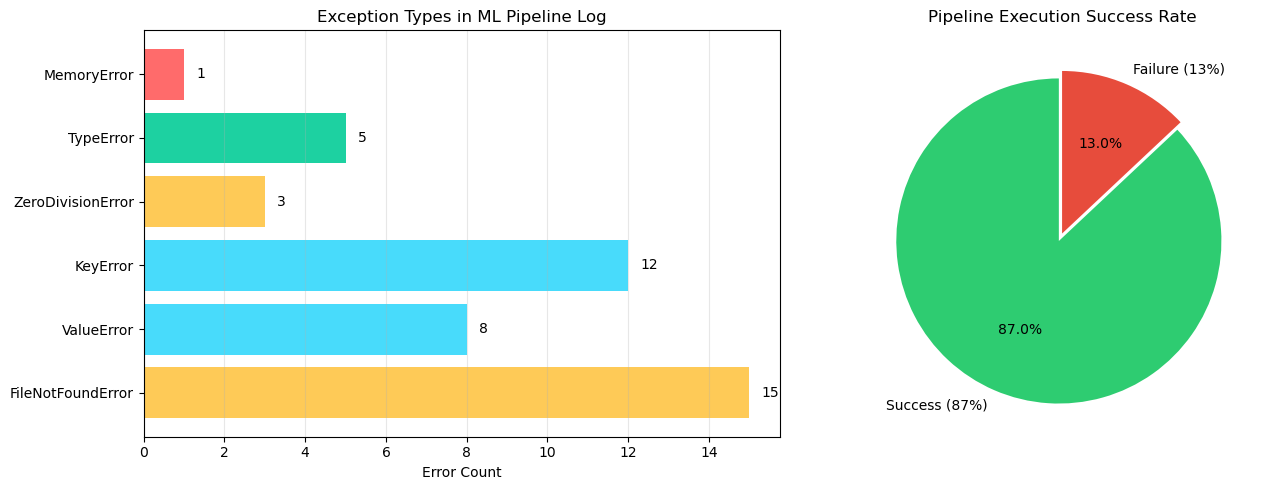

✅ Error visualization saved!


In [11]:
# Example 4: Visualizing Error Patterns with Matplotlib
import matplotlib.pyplot as plt

# Simulate error log data
error_log = [
    {'type': 'FileNotFoundError', 'count': 15, 'severity': 'high'},
    {'type': 'ValueError', 'count': 8, 'severity': 'medium'},
    {'type': 'KeyError', 'count': 12, 'severity': 'medium'},
    {'type': 'ZeroDivisionError', 'count': 3, 'severity': 'high'},
    {'type': 'TypeError', 'count': 5, 'severity': 'low'},
    {'type': 'MemoryError', 'count': 1, 'severity': 'critical'},
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of error counts
types = [e['type'] for e in error_log]
counts = [e['count'] for e in error_log]
colors = ['#ff6b6b' if e['severity'] == 'critical' else 
          '#feca57' if e['severity'] == 'high' else 
          '#48dbfb' if e['severity'] == 'medium' else '#1dd1a1' 
          for e in error_log]

ax1.barh(types, counts, color=colors)
ax1.set_xlabel('Error Count')
ax1.set_title('Exception Types in ML Pipeline Log')
ax1.grid(axis='x', alpha=0.3)

# Add count labels
for i, (t, c) in enumerate(zip(types, counts)):
    ax1.text(c + 0.3, i, str(c), va='center')

# Pie chart of success vs failure
success_rate = 0.87
failure_rate = 1 - success_rate

ax2.pie([success_rate, failure_rate], 
        labels=['Success (87%)', 'Failure (13%)'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0))
ax2.set_title('Pipeline Execution Success Rate')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Error visualization saved!')

## 🛠️ Hands-On Exercises

Complete these exercises to solidify your understanding of error handling in Python.

### Exercise 1: Basic try/except
Write a function `safe_int_convert` that takes a string and converts it to an integer. If conversion fails, return `None` instead of crashing.

In [12]:
# your code here


### Exercise 2: Catching Specific Errors
Create a function `process_list_index` that takes a list and an index. Return the element at that index if valid, or return `"Index out of range"` if IndexError occurs, or `"Invalid index type"` if TypeError occurs.

In [13]:
# your code here


### Exercise 3: File Not Found Handling
Write a function `read_config` that attempts to open a file and return its contents. If the file doesn't exist, create it with default content `{"default": true}` and return that content.

In [14]:
# your code here


### Exercise 4: Safe Division Function
Create a function `safe_divide` that takes two numbers and returns their division result. Handle `ZeroDivisionError` by returning `0`, and `TypeError` by returning `None`. Include an `else` block that prints "Division successful" and a `finally` block that prints "Operation complete".

In [15]:
# your code here


### Exercise 5: Custom Exception for Invalid Learning Rate
Create a custom exception `InvalidLearningRateError` that inherits from `ValueError`. Write a function `set_learning_rate` that raises this exception if the learning rate is not between 0 and 1.

In [16]:
# your code here


### Exercise 6: Robust CSV Reader
Write a function `load_training_data` that reads a CSV file and returns a list of dictionaries. Skip any rows that cause errors (malformed data), log a warning for each skipped row, and return all valid rows.

In [17]:
# your code here


### Exercise 7: Graceful JSON Loading
Create a function `load_model_params` that tries to load JSON from a file. If the file doesn't exist or contains invalid JSON, return default parameters `{"epochs": 10, "lr": 0.001}`.

In [18]:
# your code here


### Exercise 8: Logging Errors
Set up basic logging and create a function `train_model` that logs an INFO message when starting, a DEBUG message with hyperparameters, and an ERROR message if training fails (simulate failure with a random exception).

In [19]:
# your code here


### Exercise 9: Exception Chaining
Write a function `load_pretrained_model` that tries to load a model file. If it fails with FileNotFoundError, raise a new custom exception `ModelLoadError` that chains the original exception with the message "Failed to load pretrained weights".

In [20]:
# your code here


### Exercise 10: Context Manager Usage
Write a function `process_large_file` that opens a large file using a context manager, reads the first 100 lines, and ensures the file is closed even if an error occurs during reading.

In [21]:
# your code here


### Exercise 11: Building a Safe Data Loader
Create a comprehensive `SafeDataLoader` class with methods `load_csv`, `validate_data`, and `get_summary`. The `load_csv` method should handle all common exceptions (FileNotFound, PermissionError, empty file), `validate_data` should check for required columns and raise a custom `DataValidationError` if missing, and `get_summary` should safely return statistics even if no data is loaded.

In [22]:
# your code here


## Solutions (check after attempting)

Below are the solutions for each exercise. Review them after attempting the problems yourself.

### Solution 1: Basic try/except

In [23]:
def safe_int_convert(value):
    try:
        return int(value)
    except ValueError:
        return None
    except TypeError:
        return None

# Test
print(safe_int_convert('42'))      # 42
print(safe_int_convert('abc'))     # None
print(safe_int_convert(None))       # None

42
None
None


### Solution 2: Catching Specific Errors

In [24]:
def process_list_index(data, index):
    try:
        return data[index]
    except IndexError:
        return "Index out of range"
    except TypeError:
        return "Invalid index type"

# Test
my_list = [1, 2, 3]
print(process_list_index(my_list, 1))      # 2
print(process_list_index(my_list, 10))     # Index out of range
print(process_list_index(my_list, 'a'))    # Invalid index type

2
Index out of range
Invalid index type


### Solution 3: File Not Found Handling

In [25]:
import json
import os

def read_config(filepath):
    try:
        with open(filepath, 'r') as f:
            return f.read()
    except FileNotFoundError:
        default_content = '{"default": true}'
        with open(filepath, 'w') as f:
            f.write(default_content)
        return default_content

# Test
test_file = 'test_config.json'
if os.path.exists(test_file):
    os.remove(test_file)
print(read_config(test_file))  # Creates file and returns default
os.remove(test_file)

{"default": true}


### Solution 4: Safe Division Function

In [26]:
def safe_divide(a, b):
    try:
        result = a / b
    except ZeroDivisionError:
        return 0
    except TypeError:
        return None
    else:
        print("Division successful")
        return result
    finally:
        print("Operation complete")

# Test
print(safe_divide(10, 2))   # Success case
print(safe_divide(10, 0))   # ZeroDivisionError
print(safe_divide(10, 'a')) # TypeError

Division successful
Operation complete
5.0
Operation complete
0
Operation complete
None


### Solution 5: Custom Exception for Invalid Learning Rate

In [27]:
class InvalidLearningRateError(ValueError):
    """Raised when learning rate is outside valid range [0, 1]."""
    pass

def set_learning_rate(lr):
    if not (0 < lr < 1):
        raise InvalidLearningRateError(f'Learning rate must be between 0 and 1, got {lr}')
    return f'Learning rate set to {lr}'

# Test
try:
    print(set_learning_rate(0.01))   # Valid
    print(set_learning_rate(1.5))    # Invalid
except InvalidLearningRateError as e:
    print(f'Error: {e}')

Learning rate set to 0.01
Error: Learning rate must be between 0 and 1, got 1.5


### Solution 6: Robust CSV Reader

In [28]:
import csv
import logging

logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(__name__)

def load_training_data(filepath):
    valid_rows = []
    try:
        with open(filepath, 'r', newline='') as f:
            reader = csv.DictReader(f)
            for i, row in enumerate(reader, start=2):
                try:
                    # Validate row has data
                    if not any(row.values()):
                        raise ValueError('Empty row')
                    valid_rows.append(row)
                except Exception as e:
                    logger.warning(f'Skipping row {i}: {e}')
    except FileNotFoundError:
        logger.error(f'File not found: {filepath}')
        return []
    return valid_rows

### Solution 7: Graceful JSON Loading

In [29]:
import json

def load_model_params(filepath):
    default = {"epochs": 10, "lr": 0.001}
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except (FileNotFoundError, json.JSONDecodeError) as e:
        print(f'Warning: Could not load {filepath}, using defaults. Error: {e}')
        return default

# Test
print(load_model_params('nonexistent.json'))  # Returns default

{'epochs': 10, 'lr': 0.001}


### Solution 8: Logging Errors

In [30]:
import logging
import random

logging.basicConfig(
    level=logging.DEBUG,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger('train_model')

def train_model(params):
    logger.info('Starting model training')
    logger.debug(f'Hyperparameters: {params}')
    
    try:
        # Simulate random failure
        if random.random() < 0.5:
            raise RuntimeError('Simulated training failure')
        logger.info('Training completed successfully')
        return {'status': 'success'}
    except Exception as e:
        logger.error(f'Training failed: {e}', exc_info=True)
        return {'status': 'failed', 'error': str(e)}

# Run multiple times to see both outcomes
for i in range(3):
    result = train_model({'lr': 0.01, 'batch_size': 32})

2026-03-24 06:14:58,451 - train_model - INFO - Starting model training
2026-03-24 06:14:58,454 - train_model - ERROR - Training failed: Simulated training failure
Traceback (most recent call last):
  File "C:\Users\786\AppData\Local\Temp\ipykernel_10856\3044835607.py", line 17, in train_model
    raise RuntimeError('Simulated training failure')
RuntimeError: Simulated training failure
2026-03-24 06:14:58,458 - train_model - INFO - Starting model training
2026-03-24 06:14:58,460 - train_model - INFO - Training completed successfully
2026-03-24 06:14:58,462 - train_model - INFO - Starting model training
2026-03-24 06:14:58,465 - train_model - INFO - Training completed successfully


### Solution 9: Exception Chaining

In [31]:
class ModelLoadError(Exception):
    """Raised when model loading fails."""
    pass

def load_pretrained_model(filepath):
    try:
        with open(filepath, 'rb') as f:
            return f.read()
    except FileNotFoundError as e:
        raise ModelLoadError('Failed to load pretrained weights') from e

# Test
try:
    load_pretrained_model('missing_model.pkl')
except ModelLoadError as e:
    print(f'Caught: {e}')
    print(f'Original cause: {e.__cause__}')

Caught: Failed to load pretrained weights
Original cause: [Errno 2] No such file or directory: 'missing_model.pkl'


### Solution 10: Context Manager Usage

In [32]:
def process_large_file(filepath):
    lines = []
    try:
        with open(filepath, 'r') as f:
            for i, line in enumerate(f):
                if i >= 100:
                    break
                lines.append(line.strip())
    except Exception as e:
        print(f'Error reading file: {e}')
        return []
    finally:
        print(f'File handle closed automatically (context manager)')
    return lines

# Create test file
with open('large_test.txt', 'w') as f:
    for i in range(200):
        f.write(f'Line {i}\n')

result = process_large_file('large_test.txt')
print(f'Read {len(result)} lines')
import os
os.remove('large_test.txt')

File handle closed automatically (context manager)
Read 100 lines


### Solution 11: Building a Safe Data Loader

In [33]:
import csv
import os

class DataValidationError(Exception):
    """Raised when data validation fails."""
    pass

class SafeDataLoader:
    def __init__(self):
        self.data = []
        self.filepath = None
    
    def load_csv(self, filepath):
        """Load CSV with comprehensive error handling."""
        self.filepath = filepath
        self.data = []
        
        try:
            if not os.path.exists(filepath):
                raise FileNotFoundError(f'File not found: {filepath}')
            
            if os.path.getsize(filepath) == 0:
                raise DataValidationError('File is empty')
            
            with open(filepath, 'r', newline='', encoding='utf-8') as f:
                reader = csv.DictReader(f)
                self.data = list(reader)
                
            if not self.data:
                raise DataValidationError('No data rows found')
                
            return True
            
        except PermissionError:
            print(f'Error: Permission denied for {filepath}')
            return False
        except (FileNotFoundError, DataValidationError) as e:
            print(f'Error: {e}')
            return False
    
    def validate_data(self, required_columns):
        """Validate that required columns exist."""
        if not self.data:
            raise DataValidationError('No data loaded')
        
        available = set(self.data[0].keys())
        missing = set(required_columns) - available
        
        if missing:
            raise DataValidationError(f'Missing required columns: {missing}')
        return True
    
    def get_summary(self):
        """Safely return data statistics."""
        try:
            if not self.data:
                return {'rows': 0, 'columns': 0, 'status': 'empty'}
            return {
                'rows': len(self.data),
                'columns': len(self.data[0]),
                'status': 'loaded'
            }
        except Exception:
            return {'rows': 0, 'columns': 0, 'status': 'error'}

# Test the SafeDataLoader
loader = SafeDataLoader()

# Create test file
with open('test_data.csv', 'w') as f:
    f.write('name,age,city\nAlice,30,NYC\nBob,25,LA\n')

if loader.load_csv('test_data.csv'):
    try:
        loader.validate_data(['name', 'age'])
        print('✅ Validation passed')
    except DataValidationError as e:
        print(f'❌ {e}')

print(f'Summary: {loader.get_summary()}')
os.remove('test_data.csv')

✅ Validation passed
Summary: {'rows': 2, 'columns': 3, 'status': 'loaded'}
